In [16]:
# Install the core Hugging Face libraries
#!pip install -q transformers[torch] datasets evaluate accelerate peft

import torch

# Check for Apple Silicon GPU (MPS)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")


Using MPS (Apple Silicon GPU)


In [17]:
from transformers import pipeline

base_model_checkpoint = "distilbert-base-uncased"

base_classifier = pipeline(
    "sentiment-analysis",
    model=base_model_checkpoint,
    tokenizer=base_model_checkpoint,
    device=device
)

before_review = "This Browns quarterback can't throw passes to save his life"
base_output = base_classifier(before_review)[0]

print(f"Running on: {device}")
print("Tweet:", before_review)
print("Base model output:", base_output)

#Label 0 = Negative, Label 1 = Positive

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use mps


Running on: mps
Tweet: This Browns quarterback can't throw passes to save his life
Base model output: {'label': 'LABEL_0', 'score': 0.5167807936668396}


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load data
sentiment_df = pd.read_csv('/Users/alecxszhang/Desktop/Stat 359/student/Final_Project/nfl_sentiments.csv')

# 2. Select columns and drop rows with missing values
df = sentiment_df[['text', 'sentiment']].dropna()

# 3. Keep only the three main sentiment categories
# This removes the rare classes causing the "least populated class" error
valid_sentiments = ['neutral', 'negative', 'positive']
df = df[df['sentiment'].isin(valid_sentiments)]

# 4. First split: Separate the Test set (20% of total data)
# Stratify ensures the 20% test set has the same % of neg/neu/pos as the original
train_val, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['sentiment']
)

# 5. Second split: Separate the Remaining 80% into Train (60%) and Validation (20%)
# (0.25 of 80% = 20% of the total)
train_df, val_df = train_test_split(
    train_val, test_size=0.25, random_state=42, stratify=train_val['sentiment']
)

# Verify the results
print("Value counts after filtering:")
print(df['sentiment'].value_counts())
print("-" * 30)
print(f"Training set:   {len(train_df)} rows")
print(f"Validation set: {len(val_df)} rows")
print(f"Testing set:    {len(test_df)} rows")

Value counts after filtering:
sentiment
neutral     2235
negative    1757
positive    1161
Name: count, dtype: int64
------------------------------
Training set:   3091 rows
Validation set: 1031 rows
Testing set:    1031 rows


In [19]:
# Define label mapping
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Add integer label column to each split
for split in [train_df, val_df, test_df]:
    split["label"] = split["sentiment"].map(label2id)

print("Label mapping:", label2id)
print(train_df[["text", "sentiment", "label"]].head())

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
                                                   text sentiment  label
4897  Fancy destroying the famous One Ring on your o...   neutral      1
1260  Police Union Urges Officers To Protest Miami D...   neutral      1
2047  Sean Payton compared Broncos wide receiver Dev...   neutral      1
722   #Jets fans may not be pleased with Aaron Rodge...  negative      0
2025  Whatever you need fundraising for GiveSendGo i...  positive      2


In [20]:
from transformers import AutoTokenizer
from datasets import Dataset  

tokenizer = AutoTokenizer.from_pretrained(base_model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert pandas DataFrames → HuggingFace Datasets BEFORE calling .map()
tokenized_train_dataset = Dataset.from_pandas(train_df[["text", "label"]]).map(tokenize_function, batched=True)
tokenized_eval_dataset  = Dataset.from_pandas(val_df[["text", "label"]]).map(tokenize_function, batched=True)
tokenized_test_dataset  = Dataset.from_pandas(test_df[["text", "label"]]).map(tokenize_function, batched=True)

# Sanity check the tokenizer
sample_text = "The Browns finally won a game!"
sample_ids = tokenizer(sample_text, add_special_tokens=True)["input_ids"]
print("Sample text:", sample_text)
print("Encoded IDs:", sample_ids)
print("Decoded:", tokenizer.decode(sample_ids))
print("\nDataset features:", tokenized_train_dataset.features)

Map:   0%|          | 0/3091 [00:00<?, ? examples/s]

Map:   0%|          | 0/1031 [00:00<?, ? examples/s]

Map:   0%|          | 0/1031 [00:00<?, ? examples/s]

Sample text: The Browns finally won a game!
Encoded IDs: [101, 1996, 13240, 2633, 2180, 1037, 2208, 999, 102]
Decoded: [CLS] the browns finally won a game! [SEP]

Dataset features: {'text': Value(dtype='string', id=None), 'label': Value(dtype='int64', id=None), '__index_level_0__': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}


In [21]:
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

# ✅ Fix 1: Match the 3-class label mapping you defined in Cell 4
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    base_model_checkpoint,
    num_labels=3,          # ✅ Fix 2: Was 2, must match actual number of classes
    id2label=id2label,
    label2id=label2id,
)
model.to(device)           # ✅ Fix 3: Explicitly move model to MPS/CUDA/CPU

# Technique 1: Freeze embeddings + lower transformer layers
num_frozen_layers = 4
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:num_frozen_layers]:
    for param in layer.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Technique 2: Dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./distilbert-nfl-sentiment",   # ✅ Fix 4: Renamed to match your project
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    fp16=torch.cuda.is_available(),            # Safe: stays False on MPS/CPU
    lr_scheduler_type="cosine",
    warmup_steps=100,                          # ✅ Fix 5: Was 0.1 (float) — must be int
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 14,768,643 / 66,955,779 (22.06%)


In [22]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.653200,0.715462,0.689622
2,0.659500,0.644243,0.728419
3,0.573100,0.638041,0.734239


TrainOutput(global_step=582, training_loss=0.6981031866008064, metrics={'train_runtime': 167.8062, 'train_samples_per_second': 55.26, 'train_steps_per_second': 3.468, 'total_flos': 307098023493888.0, 'train_loss': 0.6981031866008064, 'epoch': 3.0})

In [23]:
from transformers import pipeline

# Step 1: Create the pipeline FIRST
fine_tuned_classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
)

# Step 2: Run inference on the correct text
sample_text = "Mahomes just threw an interception"
after_output = fine_tuned_classifier(sample_text)[0]

print("Sample Text:", sample_text)
print("Before fine-tuning:", base_classifier(sample_text)[0])  
print("After fine-tuning:", after_output)                       

# Step 3: Evaluate and save
eval_results = trainer.evaluate()
print("Evaluation metrics:", eval_results)

trainer.save_model("./my_fine_tuned_model")
tokenizer.save_pretrained("./my_fine_tuned_model")

Device set to use mps


Sample Text: Mahomes just threw an interception
Before fine-tuning: {'label': 'LABEL_0', 'score': 0.5136743783950806}
After fine-tuning: {'label': 'negative', 'score': 0.5668140649795532}


Evaluation metrics: {'eval_loss': 0.6380409598350525, 'eval_accuracy': 0.7342386032977691, 'eval_runtime': 8.5516, 'eval_samples_per_second': 120.562, 'eval_steps_per_second': 7.601, 'epoch': 3.0}


('./my_fine_tuned_model/tokenizer_config.json',
 './my_fine_tuned_model/special_tokens_map.json',
 './my_fine_tuned_model/vocab.txt',
 './my_fine_tuned_model/added_tokens.json',
 './my_fine_tuned_model/tokenizer.json')

In [24]:
sample_text = "I hate this game so much"
after_output = fine_tuned_classifier(sample_text)[0]

print("Sample Text:", sample_text)
print("Before fine-tuning:", base_classifier(sample_text)[0])  
print("After fine-tuning:", after_output)        

Sample Text: I hate this game so much
Before fine-tuning: {'label': 'LABEL_0', 'score': 0.5324624180793762}
After fine-tuning: {'label': 'negative', 'score': 0.9229967594146729}


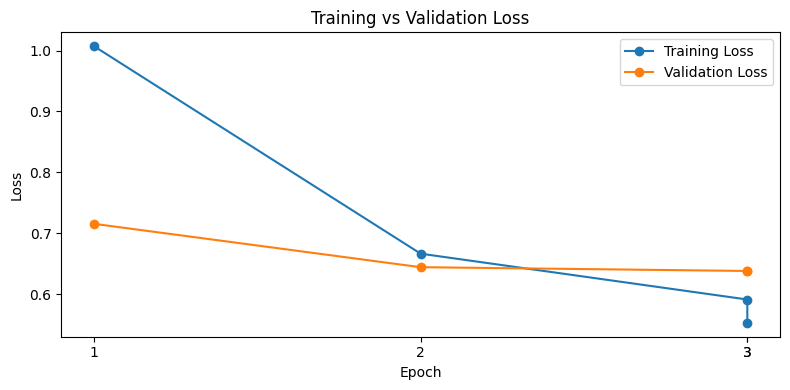

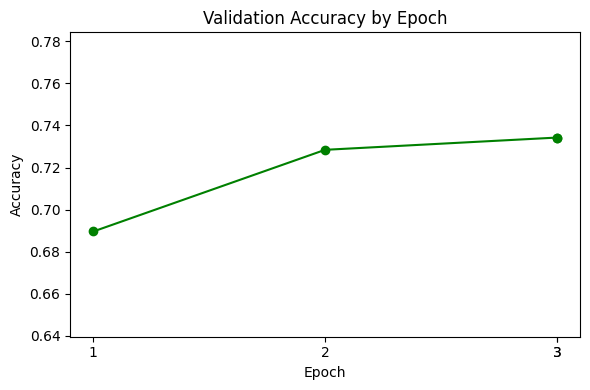

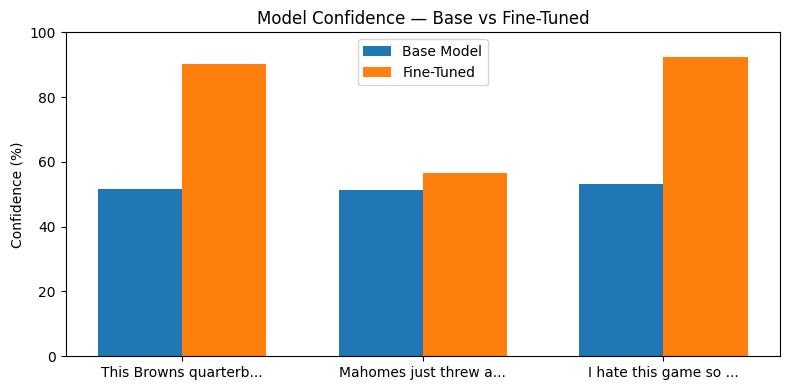

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ── Pull data from trainer logs ──────────────────────────────────────────────
log_history = trainer.state.log_history

train_loss, val_loss, val_acc, epochs = [], [], [], []

for entry in log_history:
    if 'eval_loss' in entry:
        val_loss.append(entry['eval_loss'])
        val_acc.append(entry['eval_accuracy'])
        epochs.append(int(entry['epoch']))
    if 'loss' in entry and 'eval_loss' not in entry:
        train_loss.append(entry['loss'])

# Average training loss per epoch
steps_per_epoch = len(train_loss) // len(epochs)
train_loss_per_epoch = [
    np.mean(train_loss[i * steps_per_epoch:(i + 1) * steps_per_epoch])
    for i in range(len(epochs))
]

# ── 1. Training vs Validation Loss ───────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_per_epoch, marker='o', label='Training Loss')
plt.plot(epochs, val_loss,             marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

# ── 2. Validation Accuracy ───────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
plt.plot(epochs, val_acc, marker='o', color='green')
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(max(0, min(val_acc) - 0.05), min(1.0, max(val_acc) + 0.05))
plt.tight_layout()
plt.show()

# ── 3. Base vs Fine-Tuned Confidence ─────────────────────────────────────────
sample_texts = [
    "This Browns quarterback can't throw passes to save his life",
    "Mahomes just threw an interception",
    "I hate this game so much",
]

base_conf, ft_conf, short_labels = [], [], []
for text in sample_texts:
    base_conf.append(base_classifier(text)[0]['score'] * 100)
    ft_conf.append(fine_tuned_classifier(text)[0]['score'] * 100)
    short_labels.append(text[:20] + "...")

x = np.arange(len(sample_texts))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, base_conf, width, label='Base Model')
ax.bar(x + width/2, ft_conf,   width, label='Fine-Tuned')
ax.set_title('Model Confidence — Base vs Fine-Tuned')
ax.set_ylabel('Confidence (%)')
ax.set_xticks(x)
ax.set_xticklabels(short_labels)
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

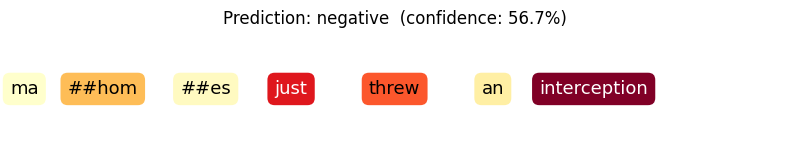

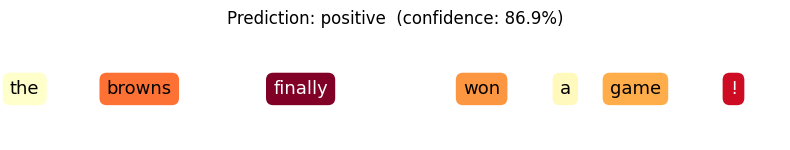

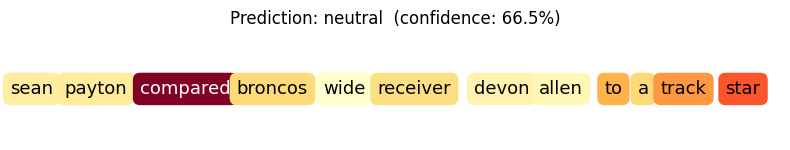

In [28]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def get_saliency(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    # Hook to capture and backprop through embeddings
    embedding_layer = model.distilbert.embeddings
    captured = {}

    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    handle = embedding_layer.register_forward_hook(forward_hook)

    # Normal full forward pass — no manual layer calls
    outputs = model(**inputs)
    handle.remove()

    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()

    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label  = id2label[predicted_class]
    score  = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency(text, model, tokenizer, device):
    tokens, saliency, label, score = get_saliency(text, model, tokenizer, device)

    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')

    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'Prediction: {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


plot_saliency("Mahomes just threw an interception", model, tokenizer, device)
plot_saliency("The Browns finally won a game!", model, tokenizer, device)
plot_saliency("Sean Payton compared Broncos wide receiver Devon Allen to a track star", model, tokenizer, device)

Red shows that the word is important

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


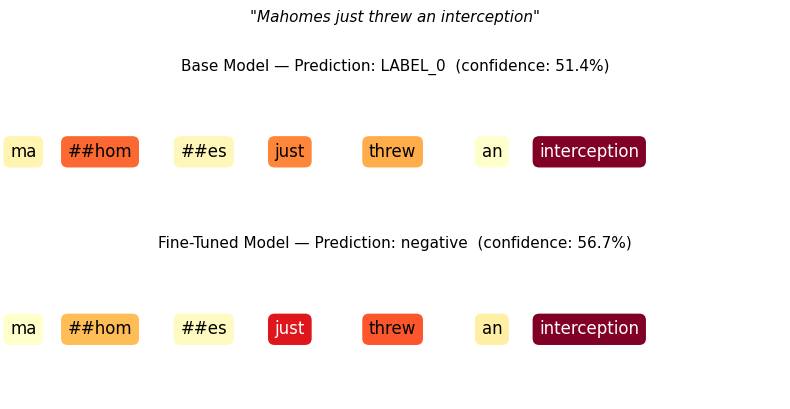

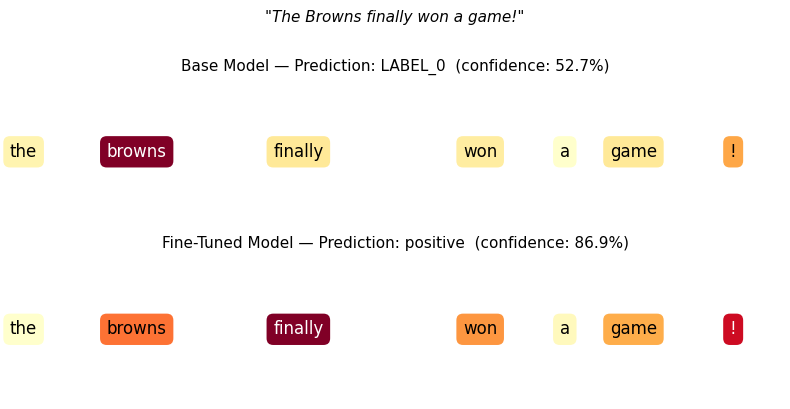

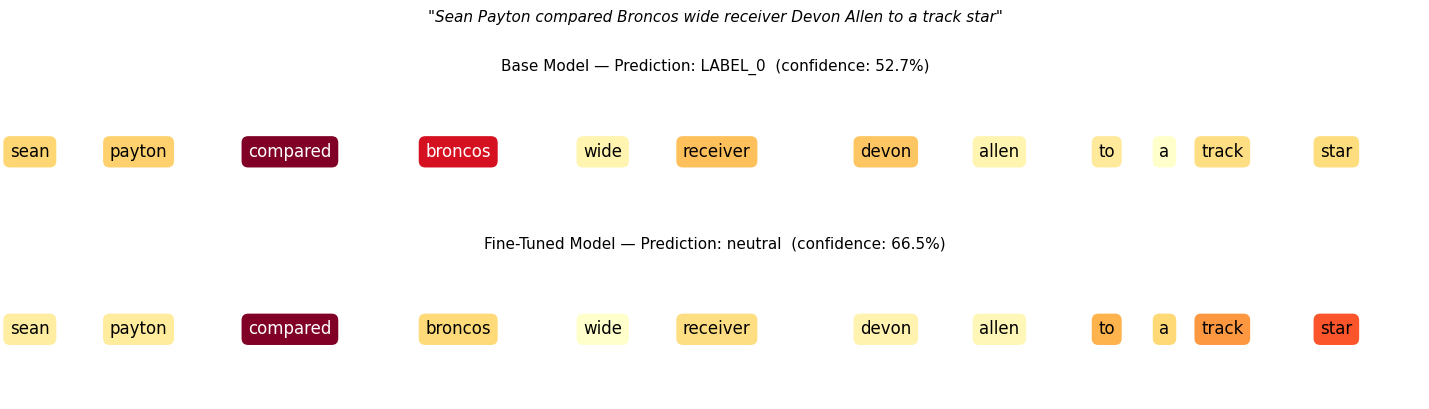

In [29]:
from transformers import AutoModelForSequenceClassification

# Load base model as a proper pytorch model (not pipeline)
base_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
base_id2label = {0: "LABEL_0", 1: "LABEL_1"}

def get_saliency_generic(text, model, tokenizer, device, id2label):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    embedding_layer = model.distilbert.embeddings
    captured = {}

    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()

    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()

    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label  = id2label[predicted_class]
    score  = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency_comparison(text, fine_tuned_model, base_model, tokenizer, device):
    fig, axes = plt.subplots(2, 1, figsize=(max(8, len(text.split()) * 1.2), 4))
    fig.suptitle(f'"{text}"', fontsize=11, style='italic', y=1.01)

    configs = [
        (base_model,        base_id2label, "Base Model"),
        (fine_tuned_model,  id2label,      "Fine-Tuned Model"),
    ]

    for ax, (mdl, lbl_map, title) in zip(axes, configs):
        tokens, saliency, label, score = get_saliency_generic(text, mdl, tokenizer, device, lbl_map)
        tokens   = tokens[1:-1]
        saliency = saliency[1:-1]
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

        ax.axis('off')
        cmap = plt.get_cmap("YlOrRd")
        x = 0
        for token, sal in zip(tokens, saliency):
            color = cmap(sal)
            ax.text(x, 0.5, token, ha='left', va='center', fontsize=12,
                    bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                    color='black' if sal < 0.7 else 'white')
            x += len(token) * 0.13 + 0.15

        ax.set_xlim(0, x)
        ax.set_ylim(0, 1)
        ax.set_title(f'{title} — Prediction: {label}  (confidence: {score:.1%})', fontsize=11, pad=8)

    plt.tight_layout()
    plt.show()


# ── Compare side by side ─────────────────────────────────────────────────────
plot_saliency_comparison("Mahomes just threw an interception", model, base_model, tokenizer, device)
plot_saliency_comparison("The Browns finally won a game!", model, base_model, tokenizer, device)
plot_saliency_comparison("Sean Payton compared Broncos wide receiver Devon Allen to a track star", model, base_model, tokenizer, device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting fine-tuned embeddings...
Extracting base model embeddings...
Done.
Running t-SNE on fine-tuned embeddings...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running t-SNE on base embeddings...
Done.


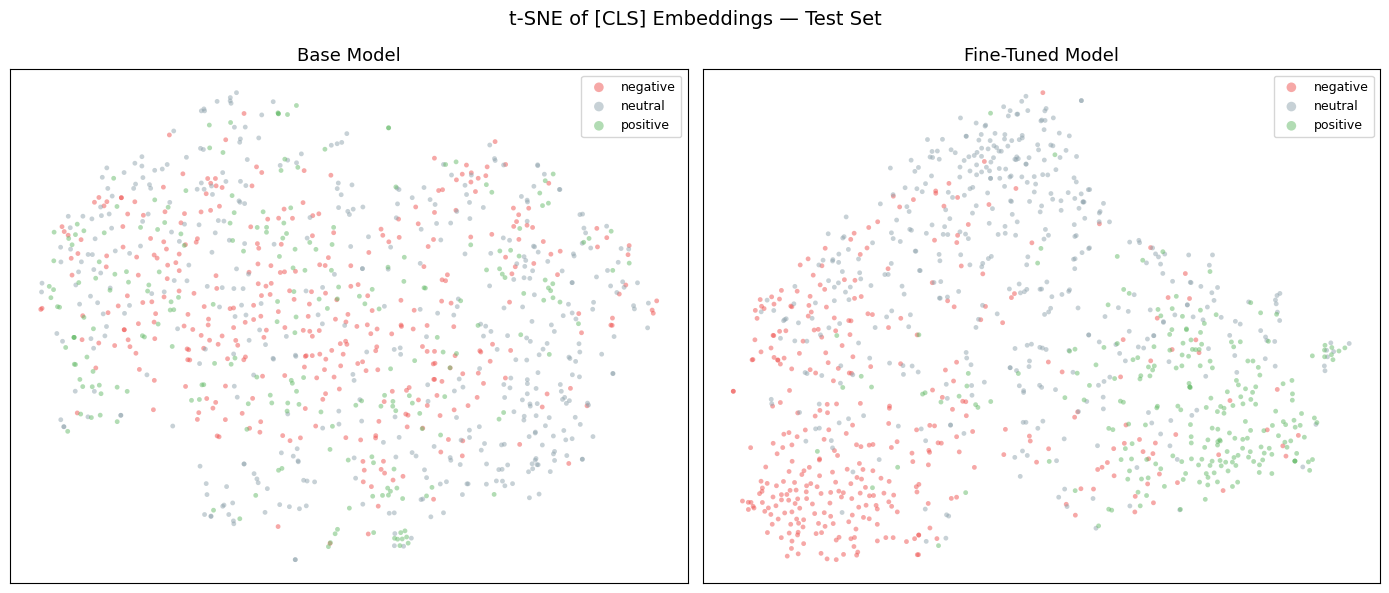

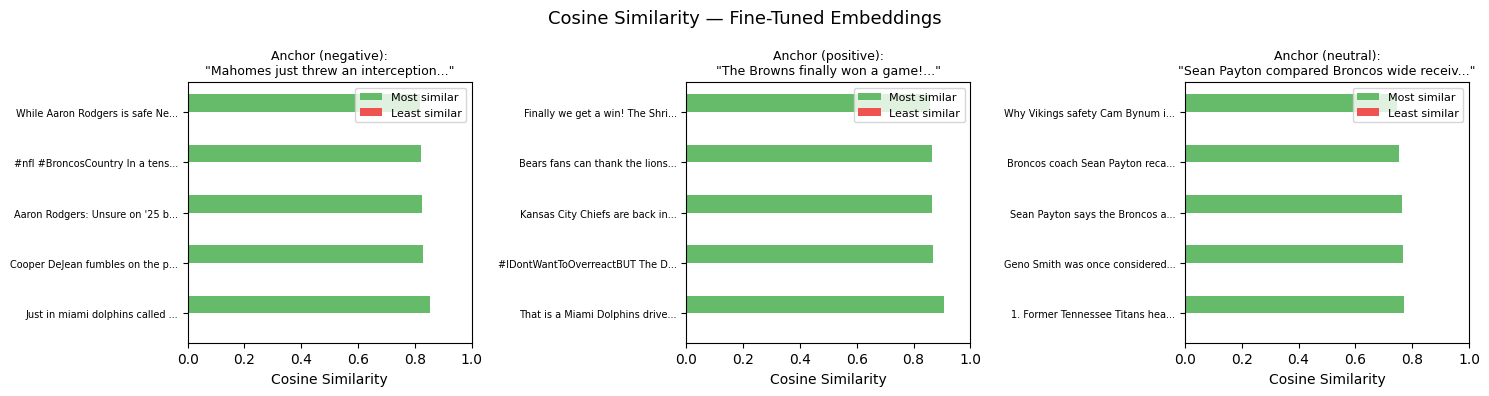

In [31]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── Step 1: Extract [CLS] embeddings for the full test set ───────────────────

def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=128, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        # [CLS] token is the first token of last hidden state
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)


# Need output_hidden_states=True — reload both models with that config
from transformers import AutoModelForSequenceClassification

base_model_emb = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    output_hidden_states=True
).to(device)

# Reload your fine-tuned model with hidden states enabled
model.config.output_hidden_states = True

texts  = test_df["text"].tolist()
labels = test_df["sentiment"].tolist()

print("Extracting fine-tuned embeddings...")
ft_embeddings   = get_cls_embeddings(texts, model, tokenizer, device)

print("Extracting base model embeddings...")
base_embeddings = get_cls_embeddings(texts, base_model_emb, tokenizer, device)
print("Done.")


# ── Step 2: t-SNE ────────────────────────────────────────────────────────────

def run_tsne(embeddings):
    # PCA to 50 dims first — speeds up t-SNE and reduces noise
    pca = PCA(n_components=50, random_state=42)
    reduced = pca.fit_transform(embeddings)
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
    return tsne.fit_transform(reduced)

print("Running t-SNE on fine-tuned embeddings...")
ft_2d   = run_tsne(ft_embeddings)

print("Running t-SNE on base embeddings...")
base_2d = run_tsne(base_embeddings)
print("Done.")


# ── Step 3: Plot ─────────────────────────────────────────────────────────────

label_colors = {"negative": "#ef5350", "neutral": "#90a4ae", "positive": "#66bb6a"}
label_array  = np.array(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, title in zip(axes, [base_2d, ft_2d], ["Base Model", "Fine-Tuned Model"]):
    for sentiment, color in label_colors.items():
        mask = label_array == sentiment
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=sentiment, alpha=0.5, s=12, edgecolors='none')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=9)

fig.suptitle("t-SNE of [CLS] Embeddings — Test Set", fontsize=14)
plt.tight_layout()
plt.show()


# ── Step 4: Cosine Similarity ─────────────────────────────────────────────────

from sklearn.metrics.pairwise import cosine_similarity

# Pick a few anchor tweets and find most/least similar in the test set
anchors = {
    "negative": "Mahomes just threw an interception",
    "positive": "The Browns finally won a game!",
    "neutral" : "Sean Payton compared Broncos wide receiver Devon Allen to a track star",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (sentiment, anchor_text) in zip(axes, anchors.items()):
    anchor_emb = get_cls_embeddings([anchor_text], model, tokenizer, device)
    sims       = cosine_similarity(anchor_emb, ft_embeddings)[0]

    # Top 5 most and least similar (excluding perfect self-match)
    ranked   = np.argsort(sims)[::-1]
    top5_idx = [i for i in ranked if texts[i] != anchor_text][:5]
    bot5_idx = ranked[-5:][::-1]

    top5_sims = sims[top5_idx]
    bot5_sims = sims[bot5_idx]

    y      = np.arange(5)
    height = 0.35

    ax.barh(y + height/2, top5_sims, height, label='Most similar',  color='#66bb6a')
    ax.barh(y - height/2, bot5_sims, height, label='Least similar', color='#ef5350')
    ax.set_yticks(y)
    ax.set_yticklabels([f"{texts[i][:30]}..." for i in top5_idx], fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Cosine Similarity')
    ax.set_title(f'Anchor ({sentiment}):\n"{anchor_text[:40]}..."', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Cosine Similarity — Fine-Tuned Embeddings", fontsize=13)
plt.tight_layout()
plt.show()

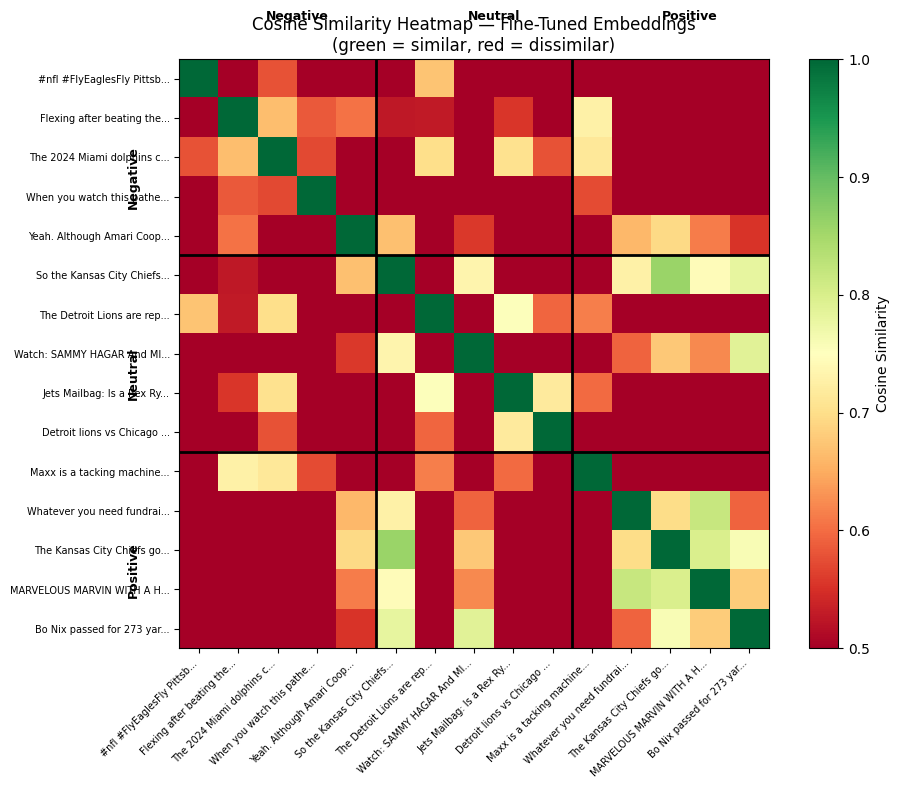

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

# Sample a few tweets from each class
n_per_class = 5
samples, sample_labels = [], []

for sentiment in ["negative", "neutral", "positive"]:
    subset = test_df[test_df["sentiment"] == sentiment].sample(n_per_class, random_state=42)
    samples.extend(subset["text"].tolist())
    sample_labels.extend(subset["sentiment"].tolist())

# Get embeddings for the sample
sample_embs = get_cls_embeddings(samples, model, tokenizer, device)
sim_matrix  = cosine_similarity(sample_embs)

# ── Plot heatmap ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, label="Cosine Similarity")

# Axis labels — truncated tweet text
short_labels = [f"{s[:25]}..." for s in samples]
ax.set_xticks(range(len(samples)))
ax.set_yticks(range(len(samples)))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)

# Draw dividing lines between sentiment groups
for i in [n_per_class, n_per_class * 2]:
    ax.axhline(i - 0.5, color="black", linewidth=2)
    ax.axvline(i - 0.5, color="black", linewidth=2)

# Label the blocks
block_centers = [n_per_class / 2, n_per_class * 1.5, n_per_class * 2.5]
for center, sentiment in zip(block_centers, ["Negative", "Neutral", "Positive"]):
    ax.text(center, -1.5, sentiment, ha="center", fontsize=9, fontweight="bold")
    ax.text(-1.5, center, sentiment, ha="right",  fontsize=9, fontweight="bold", rotation=90, va="center")

ax.set_title("Cosine Similarity Heatmap — Fine-Tuned Embeddings\n(green = similar, red = dissimilar)", fontsize=12)
plt.tight_layout()
plt.show()

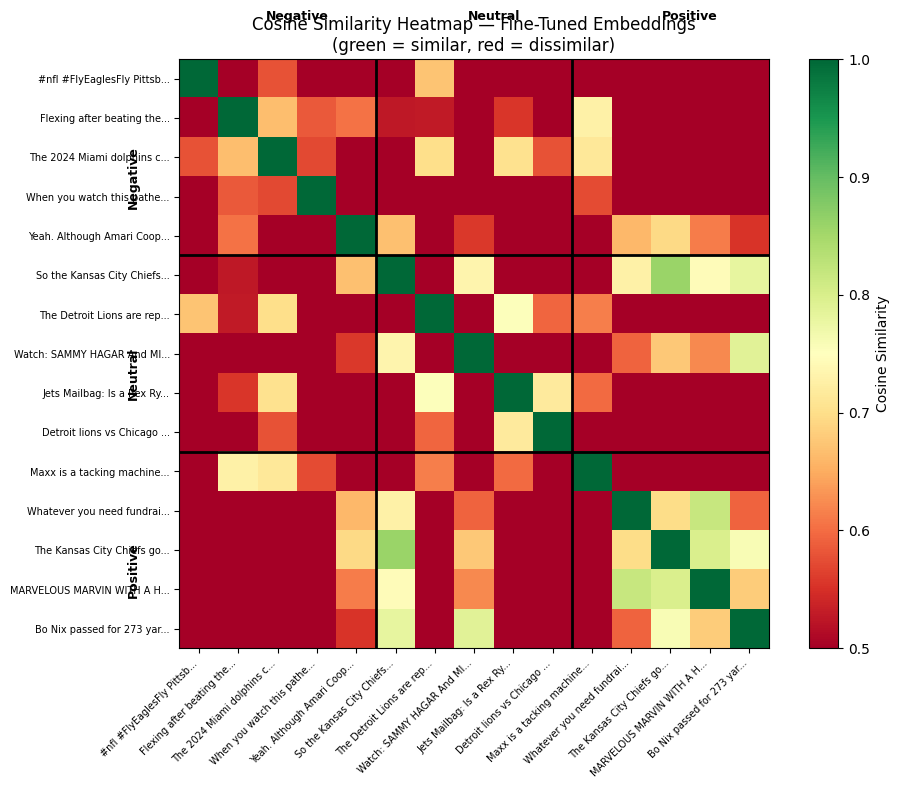

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# Sample a few tweets from each class
n_per_class = 5
samples, sample_labels = [], []

for sentiment in ["negative", "neutral", "positive"]:
    subset = test_df[test_df["sentiment"] == sentiment].sample(n_per_class, random_state=42)
    samples.extend(subset["text"].tolist())
    sample_labels.extend(subset["sentiment"].tolist())

# Get embeddings for the sample
sample_embs = get_cls_embeddings(samples, model, tokenizer, device)
sim_matrix  = cosine_similarity(sample_embs)

# ── Plot heatmap ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, label="Cosine Similarity")

# Axis labels — truncated tweet text
short_labels = [f"{s[:25]}..." for s in samples]
ax.set_xticks(range(len(samples)))
ax.set_yticks(range(len(samples)))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)

# Draw dividing lines between sentiment groups
for i in [n_per_class, n_per_class * 2]:
    ax.axhline(i - 0.5, color="black", linewidth=2)
    ax.axvline(i - 0.5, color="black", linewidth=2)

# Label the blocks
block_centers = [n_per_class / 2, n_per_class * 1.5, n_per_class * 2.5]
for center, sentiment in zip(block_centers, ["Negative", "Neutral", "Positive"]):
    ax.text(center, -1.5, sentiment, ha="center", fontsize=9, fontweight="bold")
    ax.text(-1.5, center, sentiment, ha="right",  fontsize=9, fontweight="bold", rotation=90, va="center")

ax.set_title("Cosine Similarity Heatmap — Fine-Tuned Embeddings\n(green = similar, red = dissimilar)", fontsize=12)
plt.tight_layout()
plt.show()
